In [1]:
from PIL import Image
import numpy as np
import os

input_image_array = np.empty([625,512,512,3], dtype=np.int16)
target_image_array = np.empty([625,512,512,3], dtype=np.int16)

for i in range(625):
    image_path1 = "".join(["zutphen-alles-wit-map/image_",str(i),".jpg"])
    image1 = Image.open(image_path1)
    image_array1 = np.array(image1)
    input_image_array[i] = np.delete(np.delete(np.delete(image_array1, np.s_[512::], 0),np.s_[512::], 1),np.s_[3::], 2)

    image_path2 = "".join(["zutphen-witte-labels-map/image_", str(i),".jpg"])
    image2 = Image.open(image_path2)
    image_array2 = np.array(image2)
    target_image_array[i] = np.delete(np.delete(np.delete(image_array2, np.s_[512::], 0),np.s_[512::], 1),np.s_[3::], 2)

In [2]:
input_image_array = np.mean(input_image_array, axis = 3)
input_image_array[input_image_array<128] = 0
input_image_array[input_image_array>=128] = 1
input_image_array = np.array(input_image_array, dtype = int)
print(input_image_array)
print("ok")

target_image_array = np.mean(target_image_array, axis = 3)
target_image_array[target_image_array<128] = 0
target_image_array[target_image_array>=128] = 1
target_image_array = np.array(target_image_array, dtype = int)
print(target_image_array)

[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 1 1 1]
  [0 0 0 ... 1 1 1]
  [0 0 0 ... 1 1 1]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 1 1 1]
  [0 0 0 ... 1 1 1]
  [0 0 0 ... 1 1 1]]

 ...

 [[0 0 1 ... 1 1 1]
  [0 0 1 ... 1 1 1]
  [0 0 1 ... 1 1 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 1 1 1]
  [0 0 0 ... 1 1 1]
  [0 0 0 ... 1 1 1]]]
ok
[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 

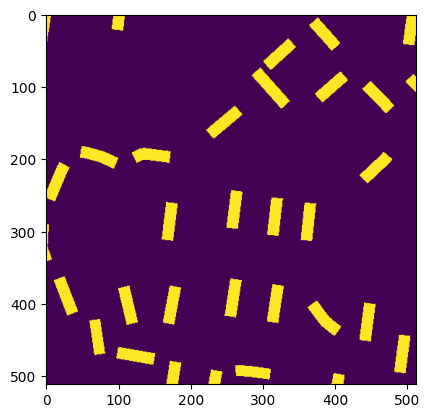

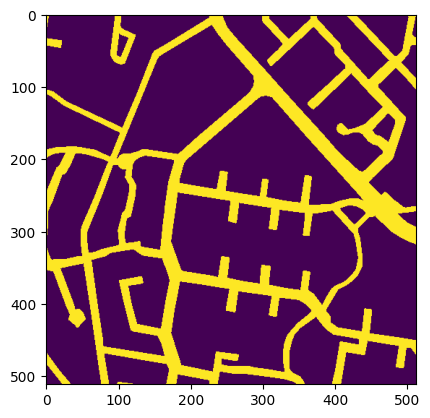

In [3]:
import matplotlib.pyplot as plt

plt.imshow(target_image_array[72])
plt.show()

plt.imshow(input_image_array[72])
plt.show()

In [37]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(input_image_array, target_image_array, test_size=0.2, random_state=42)
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)

In [40]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

def build_unet_map_labeler(heigth, width, channels):
    inputs = layers.Input((heigth, width, channels))

    # Helper function for a double convolution block
    def conv_block(x, filters):
        x = layers.Conv2D(filters, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Conv2D(filters, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        return x

    # --- ENCODER (Downsampling) ---
    f1 = conv_block(inputs, 64)
    p1 = layers.MaxPooling2D((2, 2))(f1)

    f2 = conv_block(p1, 128)
    p2 = layers.MaxPooling2D((2, 2))(f2)

    f3 = conv_block(p2, 256)
    p3 = layers.MaxPooling2D((2, 2))(f3)

    # --- BOTTLE NECK ---
    bottleneck = conv_block(p3, 512)

    # --- DECODER (Upsampling) ---
    u3 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(bottleneck)
    u3 = layers.concatenate([u3, f3])
    f4 = conv_block(u3, 256)

    u2 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(f4)
    u2 = layers.concatenate([u2, f2])
    f5 = conv_block(u2, 128)

    u1 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(f5)
    u1 = layers.concatenate([u1, f1])
    f6 = conv_block(u1, 64)

    # --- OUTPUT (Heatmap) ---
    # 1 channel (512, 512, 1) with sigmoid to get float values [0.0, 1.0]
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(f6)

    model = models.Model(inputs, outputs, name="U-Net_RoadLabeler")
    return model

# Initialize
model = build_unet_map_labeler(512,512,1)


def loss_function(y_true, y_pred):
    label_y_true = y_true[y_true == 1]
    label_y_pred = y_pred[y_true == 1]
    background_y_true = y_true[y_true == 0]
    background_y_pred = y_pred[y_true == 0]
    
    label_loss = tf.keras.losses.MSE(label_y_true, label_y_pred)
    background_loss = tf.keras.losses.MSE(background_y_true, background_y_pred)
    #as both losses are mean values, no weights are needed. Bc summing them makes them equally valuable
    loss = label_loss + background_loss
    return loss


def weighted_bce_loss(pos_weight):
    def loss(y_true, y_pred):
        return tf.reduce_mean(tf.nn.weighted_cross_entropy_with_logits(labels=y_true, logits=y_pred, pos_weight=pos_weight))
    return loss


def adaptive_wing_loss(y_true, y_pred, omega=14.0, theta=0.5, epsilon=1.0, alpha=2.1):
    """
    omega, theta, epsilon, alpha are hyperparameters 
    that control the curvature of the loss.
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    delta_y = tf.abs(y_true - y_pred)
    
    # Adaptive factor
    A = omega * (1.0 / (1.0 + tf.pow(theta / epsilon, alpha - y_true))) * (alpha - y_true) * tf.pow(theta / epsilon, alpha - y_true - 1.0) * (1.0 / epsilon)
    C = (theta * A - omega * tf.math.log(1.0 + tf.pow(theta / epsilon, alpha - y_true)))
    
    loss = tf.where(delta_y < theta,
                    omega * tf.math.log(1.0 + tf.pow(delta_y / epsilon, alpha - y_true)),
                    A * delta_y - C)
    
    return tf.reduce_mean(loss)


model.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss=adaptive_wing_loss, metrics=['mae'])

model.summary()

Model: "U-Net_RoadLabeler"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │      1,024 │ conv2d_4[0][0]  

 Total params: 7,707,457 (29.40 MB)

 Trainable params: 7,701,825 (29.38 MB)

 Non-trainable params: 5,632 (22.00 KB)

In [46]:
history = model.fit(x_train, y_train, epochs=50, batch_size=5, validation_data=(x_test, y_test))

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - loss: 0.5699 - mae: 0.1188 - val_loss: 0.6726 - val_mae: 0.1719
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - loss: 0.5184 - mae: 0.0937 - val_loss: 0.5758 - val_mae: 0.1302
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - loss: 0.5124 - mae: 0.0874 - val_loss: 0.5759 - val_mae: 0.1046
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - loss: 0.5062 - mae: 0.0835 - val_loss: 0.5325 - val_mae: 0.0877
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - loss: 0.5014 - mae: 0.0784 - val_loss: 0.5281 - val_mae: 0.0778
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - loss: 0.4994 - mae: 0.0762 - val_loss: 0.5283 - val_mae: 0.0724
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - loss: 0.4984 - mae: 0.0748 - val_loss: 0.5262 - val_mae: 0.0708
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - loss: 0.4981 - mae: 0.0738 - val_loss: 0.5302 - val_mae: 0.0834
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/

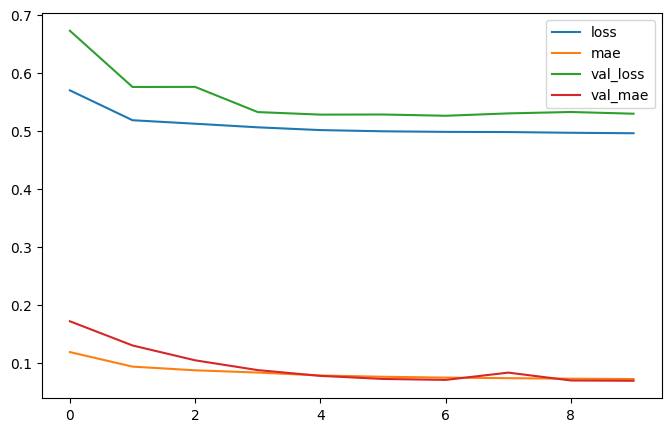

In [47]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step


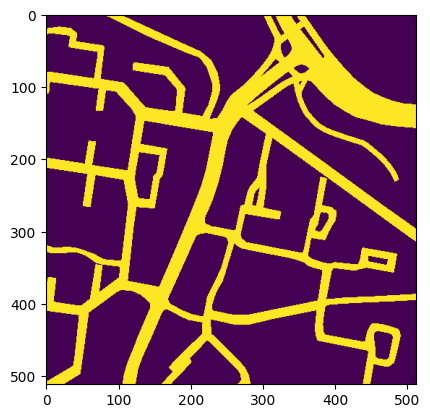

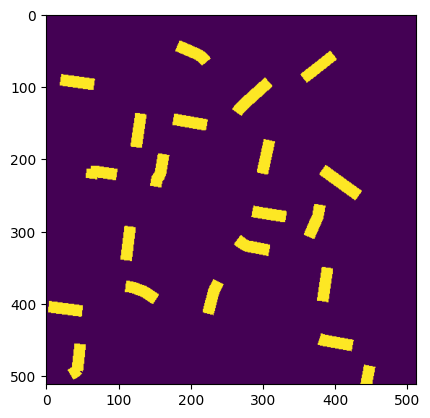

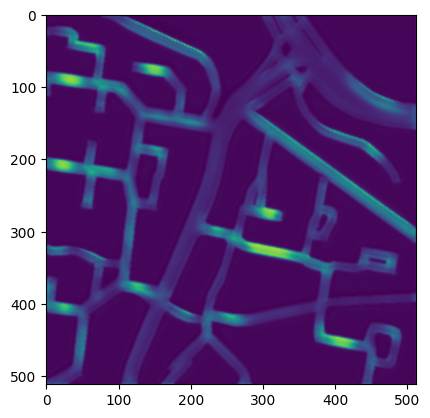

In [54]:
prediction = model.predict(x_train)
plt.imshow(x_train[100])
plt.show()
plt.imshow(y_train[100])
plt.show()
plt.imshow(prediction[100])
plt.show()

#class imbalence problem, the model has found that, as most pixels are 1 rather than 0 (target), a good fit would be to simply estimate 1 for each pixel. 
#To solve this problem ensure that the loss function is not based on MSE or binary entopy, but rather dice loss

In [ ]:
model.save("U_Net2.keras")

In [52]:
import tensorflow as tf
unet = tf.keras.models.load_model('U_Net2.keras')

TypeError: Could not locate function 'adaptive_wing_loss'. Make sure custom classes and functions are decorated with `@keras.saving.register_keras_serializable()`. If they are already decorated, make sure they are all imported so that the decorator is run before trying to load them. Full object config: {'module': 'builtins', 'class_name': 'function', 'config': 'adaptive_wing_loss', 'registered_name': 'function'}

In [53]:
print(unet.loss)

<LossFunctionWrapper(<function dice at 0x7f74f0383130>, kwargs={'axis': None})>


In [38]:
prediction = unet.predict(x_test)

ValueError: Exception encountered when calling Functional.call().

[1mInvalid input shape for input Tensor("U-Net_RoadLabeler_1/Cast:0", shape=(32, 512, 512), dtype=float32). Expected shape (None, 512, 512, 3), but input has incompatible shape (32, 512, 512)[0m

Arguments received by Functional.call():
  • inputs=tf.Tensor(shape=(32, 512, 512), dtype=int64)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [36]:
plt.imshow(prediction[10])
plt.show()

NameError: name 'prediction' is not defined

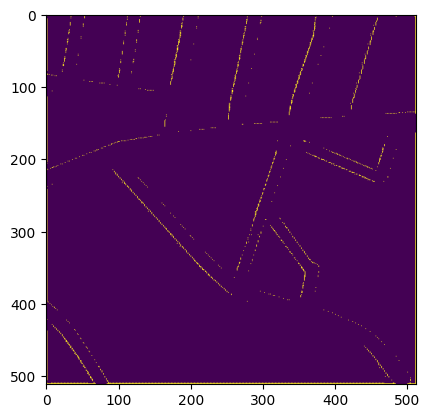

In [29]:
plt.imshow(prediction[10]**100000000)

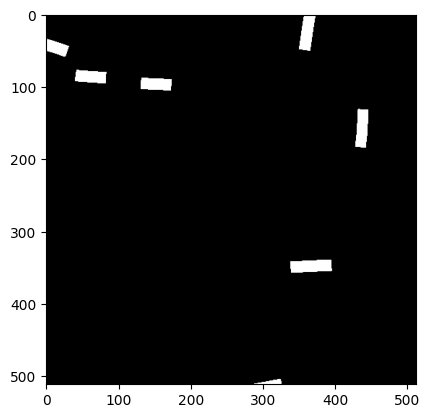

In [30]:
plt.imshow(y_test[0])

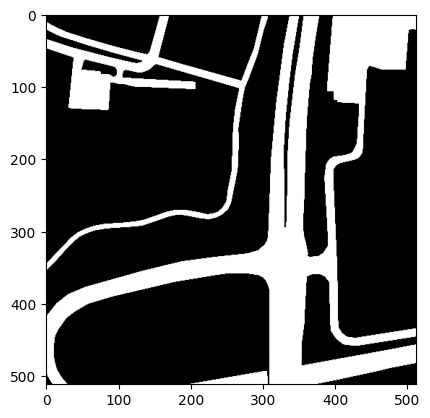

In [31]:
plt.imshow(x_test[0])

In [19]:
print(unet.summary())

Model: "U-Net_RoadLabeler"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │      1,024 │ conv2d_4[0][0]  

 Total params: 23,114,565 (88.18 MB)

 Trainable params: 7,702,977 (29.38 MB)

 Non-trainable params: 5,632 (22.00 KB)

 Optimizer params: 15,405,956 (58.77 MB)

None
